# Manual keyboard balancing and data logger

Use the keyboard to manually move the rotary arm while trying to keep the pendulum upright.

**Controls**
- `Left` / `A`: negative motor velocity
- `Right` / `D`: positive motor velocity
- `Up` / `W`: increase command magnitude
- `Down` / `S`: decrease command magnitude
- `Space`: request hard stop and latch manual E-stop
- `R`: clear the manual E-stop latch (firmware safety still applies)
- `Esc`: stop the experiment, save data, and generate plots

The notebook logs every observation returned by the firmware and every control input sent to it. Data are saved as CSV and plots as PNG when the run ends.

> Safety: start with a small command speed and keep hands clear of the mechanism.


In [1]:
from control_comms import ControlComms, StatusCode, DebugLevel, find_board_port
from pynput import keyboard
from pathlib import Path
from datetime import datetime
import threading
import time
import math
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Connection and experiment settings
SERIAL_PORT = find_board_port()   # auto-detects the ST-Link port; pass "COM10" to force one
BAUD_RATE = 500000
TIMEOUT = 0.25

# Firmware command IDs
CMD_SET_HOME = 0
CMD_MOVE_TO = 1
CMD_MOVE_BY = 2
CMD_SET_STEP_MODE = 3
CMD_SET_VELOCITY = 4
CMD_HARD_STOP = 5
CMD_QUERY = 6
CMD_RESET_SAFETY = 7

STEP_MODE_16 = 4

# Manual-control settings
INITIAL_SPEED_PPS = 250.0
SPEED_STEP_PPS = 50.0

# Must match PendulumController.ino. set_signed_velocity() turns any command
# below MOTOR_MIN_SPEED_PPS into a hard stop and clips anything above
# MOTOR_MAX_SPEED_PPS, so the host keeps the speed setting inside that band --
# otherwise pressing Down twice would silently leave the motor dead.
MOTOR_MIN_SPEED_PPS = 200.0
MOTOR_MAX_SPEED_PPS = 1000.0
CONTROL_PERIOD_S = 0.02     # target logging/query period (~50 Hz)
CONTROL_SIGN = 1.0          # change to -1 if left/right direction is reversed

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


Found the board on COM10.


In [3]:
# Connect
ctrl = ControlComms(timeout=TIMEOUT, debug_level=DebugLevel.DEBUG_ERROR)
ret = ctrl.connect(SERIAL_PORT, BAUD_RATE)
if ret is not StatusCode.OK:
    raise RuntimeError(f"Could not connect to {SERIAL_PORT}")

# Put the firmware in a known state
ctrl.step(CMD_HARD_STOP, [0.0])
ctrl.step(CMD_SET_STEP_MODE, [STEP_MODE_16])
ctrl.step(CMD_SET_HOME, [0.0])
ctrl.step(CMD_RESET_SAFETY, [0.0])

print("Connected.")
print("Use Left/Right or A/D to move, Up/Down or W/S to change speed.")
print("Space = hard stop latch, R = clear manual latch, Esc = finish/save.")


Connected.
Use Left/Right or A/D to move, Up/Down or W/S to change speed.
Space = hard stop latch, R = clear manual latch, Esc = finish/save.


## Rotate the arm by ±90°

Run the helper cell once, then run either of the two cells below to jog the arm
immediately — no keyboard listener involved. Needs the cells above (imports,
settings, **Connect**) to have been run first.

`CMD_MOVE_BY` takes a **relative angle in degrees**. The firmware soft-limits the
rotor to ±90°, so the target is clipped to stay just inside that; otherwise the
rotor parks exactly on the limit and the next velocity command latches the E-stop.


In [4]:
# Helper: one-shot relative rotation
import time

STATUS_OK = 0
STATUS_MOVING = 1
STATUS_LIMIT = 2
STATUS_DRIVER_FAULT = 3

# Must match ROTOR_LIMIT_ENABLED / ROTOR_SOFT_LIMIT_DEG in PendulumController.ino.
# With the limit enforced the margin keeps the rotor off the firmware limit, where the
# next velocity command would latch the E-stop. With it disabled the rotor turns freely.
ROTOR_LIMIT_ENABLED = False
ROTOR_SOFT_LIMIT_DEG = 90.0
ROTOR_MOVE_MARGIN_DEG = 2.0
MOVE_TIMEOUT_S = 8.0


def read_rotor():
    """Query the board once. Returns (rotor_deg, status, terminated)."""
    resp = ctrl.step(CMD_QUERY, [0.0])
    if resp is None:
        raise RuntimeError("No response from the firmware. Is the board still connected?")
    status, _, terminated, obs = resp
    return float(obs[1]), int(status), bool(terminated)


def rotate_by_deg(delta_deg, timeout_s=MOVE_TIMEOUT_S, poll_s=0.02):
    """Rotate the arm by delta_deg relative to where it is now, and wait until it stops.

    The move is clipped so the rotor stops short of the firmware soft limit.
    Returns the rotor angle it ended at, in degrees.
    """
    start, status, terminated = read_rotor()
    if terminated or status in (STATUS_LIMIT, STATUS_DRIVER_FAULT):
        raise RuntimeError(
            f"Safety is latched (status={status}, rotor={start:.1f} deg). "
            "Run ctrl.step(CMD_RESET_SAFETY, [0.0]) first."
        )

    if ROTOR_LIMIT_ENABLED:
        limit = ROTOR_SOFT_LIMIT_DEG - ROTOR_MOVE_MARGIN_DEG
        target = max(-limit, min(limit, start + delta_deg))
        move = target - start
    else:
        limit = float("inf")
        move = delta_deg
    if abs(move) < 0.5:
        print(f"Rotor is at {start:.1f} deg; no room to move {delta_deg:+.0f} deg.")
        return start
    if abs(move - delta_deg) > 0.5:
        print(f"Clipped {delta_deg:+.0f} -> {move:+.1f} deg to stay inside +/-{limit:.0f} deg.")

    # move_stepper_by() is ignored while the driver is still running.
    ctrl.step(CMD_HARD_STOP, [0.0])
    ctrl.step(CMD_MOVE_BY, [move])

    deadline = time.perf_counter() + timeout_s
    end = start
    while time.perf_counter() < deadline:
        time.sleep(poll_s)
        end, status, _ = read_rotor()
        if status != STATUS_MOVING:
            break
    else:
        ctrl.step(CMD_HARD_STOP, [0.0])
        raise TimeoutError(f"Move did not finish within {timeout_s:.1f} s (rotor {end:.1f} deg).")

    achieved = end - start
    if abs(achieved) < 0.5:
        print("The motor did not move: safety latched, or the driver was still busy.")
    print(f"{start:+.1f} -> {end:+.1f} deg  (moved {achieved:+.1f} deg)")
    return end


print("Ready. Run rotate_by_deg(+90) or rotate_by_deg(-90).")


Ready. Run rotate_by_deg(+90) or rotate_by_deg(-90).


In [76]:
# Rotate +90 deg
rotate_by_deg(+10.0)


The motor did not move: safety latched, or the driver was still busy.
+100.7 -> +100.7 deg  (moved +0.0 deg)


100.69

In [15]:
# Rotate -90 deg
rotate_by_deg(-90)


+0.0 -> +270.0 deg  (moved +270.0 deg)


270.0

In [12]:
# Shared keyboard state
state = {
    "left": False,
    "right": False,
    "speed_pps": INITIAL_SPEED_PPS,
    "stop_requested": False,
    "emergency_stop": False,
}
state_lock = threading.Lock()

def _set_motion_key(name, pressed):
    with state_lock:
        state[name] = pressed

def on_press(key):
    try:
        ch = key.char.lower()
    except AttributeError:
        ch = None

    if key == keyboard.Key.left or ch == "a":
        _set_motion_key("left", True)
    elif key == keyboard.Key.right or ch == "d":
        _set_motion_key("right", True)
    elif key == keyboard.Key.up or ch == "w":
        with state_lock:
            state["speed_pps"] = min(MOTOR_MAX_SPEED_PPS, state["speed_pps"] + SPEED_STEP_PPS)
            note = "  (firmware maximum)" if state["speed_pps"] >= MOTOR_MAX_SPEED_PPS else ""
            print(f"speed = {state['speed_pps']:.0f} pps{note}")
    elif key == keyboard.Key.down or ch == "s":
        with state_lock:
            state["speed_pps"] = max(MOTOR_MIN_SPEED_PPS, state["speed_pps"] - SPEED_STEP_PPS)
            note = "  (firmware minimum; below this the motor stops)" if state["speed_pps"] <= MOTOR_MIN_SPEED_PPS else ""
            print(f"speed = {state['speed_pps']:.0f} pps{note}")
    elif key == keyboard.Key.space:
        # Do not use the serial port from this keyboard thread.
        # The main loop sees this latch and issues CMD_HARD_STOP on the next cycle.
        with state_lock:
            state["emergency_stop"] = True
            state["left"] = False
            state["right"] = False
        print("HARD STOP requested")
    elif ch == "r":
        with state_lock:
            state["emergency_stop"] = False
            state["left"] = False
            state["right"] = False
        print("Manual E-stop latch cleared")
    elif key == keyboard.Key.esc:
        with state_lock:
            state["stop_requested"] = True
        return False

def on_release(key):
    try:
        ch = key.char.lower()
    except AttributeError:
        ch = None
    if key == keyboard.Key.left or ch == "a":
        _set_motion_key("left", False)
    elif key == keyboard.Key.right or ch == "d":
        _set_motion_key("right", False)


In [ ]:
def wrapped_error_deg(angle_deg, setpoint_deg=180.0):
    return (setpoint_deg - angle_deg + 180.0) % 360.0 - 180.0

records = []
session_start_wall = time.time()
session_start_perf = time.perf_counter()
prev_host_t = None
prev_pendulum = None
prev_rotor = None
last_sent_velocity = None

listener = keyboard.Listener(on_press=on_press, on_release=on_release)
listener.start()

print("Manual balancing started. Press Esc to finish.")

try:
    while True:
        loop_start = time.perf_counter()

        with state_lock:
            left = state["left"]
            right = state["right"]
            speed_pps = state["speed_pps"]
            stop_requested = state["stop_requested"]
            estop = state["emergency_stop"]

        if stop_requested:
            break

        if estop:
            requested_velocity = 0.0
        elif left and not right:
            requested_velocity = -CONTROL_SIGN * speed_pps
        elif right and not left:
            requested_velocity = CONTROL_SIGN * speed_pps
        else:
            requested_velocity = 0.0

        # Send a new velocity only when the requested input changes.
        # Otherwise query the board so observations continue to be sampled.
        if last_sent_velocity is None or requested_velocity != last_sent_velocity:
            command_sent = CMD_SET_VELOCITY if requested_velocity != 0.0 else CMD_HARD_STOP
            action_sent = requested_velocity if requested_velocity != 0.0 else 0.0
            resp = ctrl.step(command_sent, [action_sent])
            last_sent_velocity = requested_velocity
        else:
            command_sent = CMD_QUERY
            action_sent = requested_velocity
            resp = ctrl.step(CMD_QUERY, [0.0])

        host_elapsed = time.perf_counter() - session_start_perf
        host_unix = time.time()

        if resp is not None:
            status, mcu_timestamp_ms, terminated, obs = resp
            pendulum_deg = float(obs[0]) if len(obs) > 0 else math.nan
            rotor_deg = float(obs[1]) if len(obs) > 1 else math.nan
            motor_speed_pps = float(obs[2]) if len(obs) > 2 else math.nan
            l6474_status = int(obs[3]) if len(obs) > 3 else -1

            dt = math.nan if prev_host_t is None else host_elapsed - prev_host_t
            pendulum_velocity_dps = math.nan
            rotor_velocity_dps = math.nan
            if prev_host_t is not None and dt > 0:
                dp = (pendulum_deg - prev_pendulum + 180.0) % 360.0 - 180.0
                pendulum_velocity_dps = dp / dt
                rotor_velocity_dps = (rotor_deg - prev_rotor) / dt

            records.append({
                "host_unix_s": host_unix,
                "host_elapsed_s": host_elapsed,
                "mcu_timestamp_ms": int(mcu_timestamp_ms),
                "mcu_elapsed_s": (int(mcu_timestamp_ms) - records[0]["mcu_timestamp_ms"]) / 1000.0 if records else 0.0,
                "response_status": int(status),
                "terminated": bool(terminated),
                "pendulum_angle_deg": pendulum_deg,
                "pendulum_error_deg": wrapped_error_deg(pendulum_deg),
                "pendulum_velocity_dps_est": pendulum_velocity_dps,
                "rotor_angle_deg": rotor_deg,
                "rotor_velocity_dps_est": rotor_velocity_dps,
                "motor_speed_pps_observed": motor_speed_pps,
                "l6474_status_raw": l6474_status,
                "command_id_sent": int(command_sent),
                "command_velocity_pps": float(requested_velocity),
                "manual_speed_setting_pps": float(speed_pps),
                "key_left": bool(left),
                "key_right": bool(right),
                "emergency_stop": bool(estop),
            })

            prev_host_t = host_elapsed
            prev_pendulum = pendulum_deg
            prev_rotor = rotor_deg

            if terminated:
                print("Firmware reported termination/safety condition.")
                break

        elapsed = time.perf_counter() - loop_start
        if elapsed < CONTROL_PERIOD_S:
            time.sleep(CONTROL_PERIOD_S - elapsed)

finally:
    try:
        ctrl.step(CMD_HARD_STOP, [0.0])
    except Exception:
        pass
    try:
        listener.stop()
    except Exception:
        pass

print(f"Stopped. Samples collected: {len(records)}")


Manual balancing started. Press Esc to finish.
Manual E-stop latch cleared
speed = 200 pps
HARD STOP requested
speed = 150 pps
HARD STOP requested
HARD STOP requested
speed = 100 pps
HARD STOP requested
HARD STOP requested
HARD STOP requested
HARD STOP requested
speed = 50 pps
speed = 0 pps
HARD STOP requested
HARD STOP requested
HARD STOP requested
HARD STOP requested
speed = 0 pps
speed = 0 pps
HARD STOP requested
speed = 0 pps
speed = 0 pps
HARD STOP requested
HARD STOP requested
Manual E-stop latch cleared
speed = 50 pps


In [7]:
# Save all measured observations and control inputs
df = pd.DataFrame(records)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = DATA_DIR / f"manual_balance_{stamp}.csv"
png_path = DATA_DIR / f"manual_balance_{stamp}.png"

df.to_csv(csv_path, index=False)
print(f"CSV saved: {csv_path.resolve()}")

display(df.head())
display(df.tail())
print(df.describe(include="all"))


CSV saved: C:\Users\Sim\Dropbox\[Courses]\[고급딥러닝시스템과응용]\08_Claude\Pendulum_control\data\manual_balance_20260907_214248.csv


,host_unix_s,host_elapsed_s,mcu_timestamp_ms,mcu_elapsed_s,response_status,terminated,pendulum_angle_deg,pendulum_error_deg,pendulum_velocity_dps_est,rotor_angle_deg,rotor_velocity_dps_est,motor_speed_pps_observed,l6474_status_raw,command_id_sent,command_velocity_pps,manual_speed_setting_pps,key_left,key_right,emergency_stop
0,1.788785e+09,0.019784,50441,0.000,0,False,359.7,-179.7,NaN,0.0,NaN,NaN,-1,5,0.0,250.0,False,False,False
1,1.788785e+09,0.039273,50462,0.021,0,False,359.7,-179.7,0.0,0.0,0.0,NaN,-1,6,0.0,250.0,False,False,False
2,1.788785e+09,0.060361,50482,0.041,0,False,359.7,-179.7,0.0,0.0,0.0,NaN,-1,6,0.0,250.0,False,False,False
3,1.788785e+09,0.080147,50503,0.062,0,False,359.7,-179.7,0.0,0.0,0.0,NaN,-1,6,0.0,250.0,False,False,False
4,1.788785e+09,0.101872,50523,0.082,0,False,359.7,-179.7,0.0,0.0,0.0,NaN,-1,6,0.0,250.0,False,False,False


,host_unix_s,host_elapsed_s,mcu_timestamp_ms,mcu_elapsed_s,response_status,terminated,pendulum_angle_deg,pendulum_error_deg,pendulum_velocity_dps_est,rotor_angle_deg,rotor_velocity_dps_est,motor_speed_pps_observed,l6474_status_raw,command_id_sent,command_velocity_pps,manual_speed_setting_pps,key_left,key_right,emergency_stop
479,1.788785e+09,9.775920,60275,9.834,0,False,359.7,-179.7,0.0,0.0,0.0,NaN,-1,6,0.0,250.0,False,False,False
480,1.788785e+09,9.796381,60295,9.854,0,False,359.7,-179.7,0.0,0.0,0.0,NaN,-1,6,0.0,250.0,False,False,False
481,1.788785e+09,9.817053,60316,9.875,0,False,359.7,-179.7,0.0,0.0,0.0,NaN,-1,6,0.0,250.0,False,False,False
482,1.788785e+09,9.838455,60336,9.895,0,False,359.7,-179.7,0.0,0.0,0.0,NaN,-1,6,0.0,250.0,False,False,False
483,1.788785e+09,9.857573,60356,9.915,0,False,359.7,-179.7,0.0,0.0,0.0,NaN,-1,6,0.0,250.0,False,False,False


         host_unix_s  host_elapsed_s  mcu_timestamp_ms  mcu_elapsed_s  \
count   4.840000e+02      484.000000        484.000000     484.000000   
unique           NaN             NaN               NaN            NaN   
top              NaN             NaN               NaN            NaN   
freq             NaN             NaN               NaN            NaN   
mean    1.788785e+09        4.937199      55397.175620       4.956176   
std     2.849103e+00        2.849104       2871.418859       2.871419   
min     1.788785e+09        0.019784      50441.000000       0.000000   
25%     1.788785e+09        2.476142      52916.750000       2.475750   
50%     1.788785e+09        4.938822      55398.000000       4.957000   
75%     1.788785e+09        7.397294      57876.250000       7.435250   
max     1.788785e+09        9.857573      60356.000000       9.915000   

        response_status terminated  pendulum_angle_deg  pendulum_error_deg  \
count             484.0        484        4.8

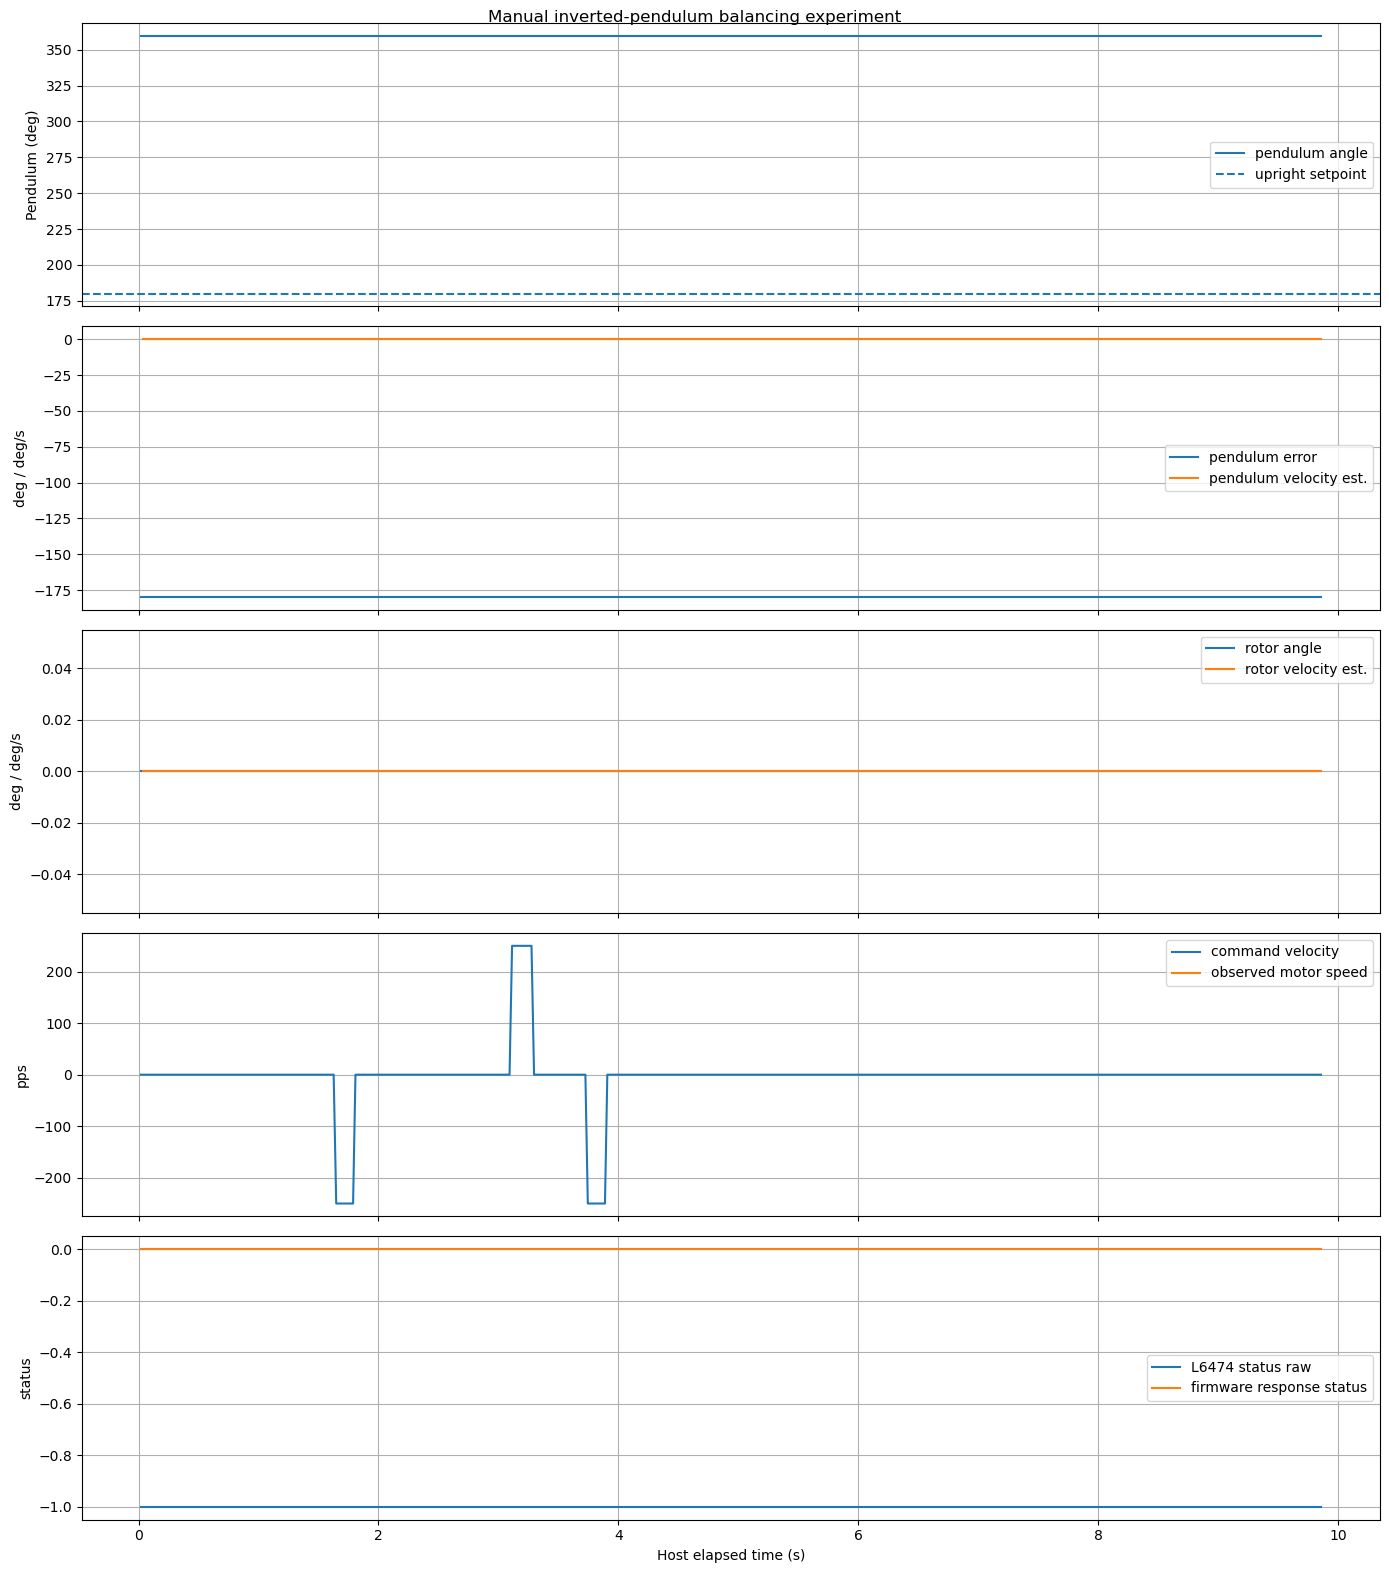

Plot saved: C:\Users\Sim\Dropbox\[Courses]\[고급딥러닝시스템과응용]\08_Claude\Pendulum_control\data\manual_balance_20260907_214248.png


In [8]:
# Plot the full experiment
if len(df) == 0:
    raise RuntimeError("No samples were recorded.")

t = df["host_elapsed_s"]

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

axes[0].plot(t, df["pendulum_angle_deg"], label="pendulum angle")
axes[0].axhline(180.0, linestyle="--", label="upright setpoint")
axes[0].set_ylabel("Pendulum (deg)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, df["pendulum_error_deg"], label="pendulum error")
axes[1].plot(t, df["pendulum_velocity_dps_est"], label="pendulum velocity est.")
axes[1].set_ylabel("deg / deg/s")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(t, df["rotor_angle_deg"], label="rotor angle")
axes[2].plot(t, df["rotor_velocity_dps_est"], label="rotor velocity est.")
axes[2].set_ylabel("deg / deg/s")
axes[2].legend()
axes[2].grid(True)

axes[3].plot(t, df["command_velocity_pps"], label="command velocity")
axes[3].plot(t, df["motor_speed_pps_observed"], label="observed motor speed")
axes[3].set_ylabel("pps")
axes[3].legend()
axes[3].grid(True)

axes[4].plot(t, df["l6474_status_raw"], label="L6474 status raw")
axes[4].plot(t, df["response_status"], label="firmware response status")
axes[4].set_ylabel("status")
axes[4].set_xlabel("Host elapsed time (s)")
axes[4].legend()
axes[4].grid(True)

fig.suptitle("Manual inverted-pendulum balancing experiment")
fig.tight_layout()
fig.savefig(png_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Plot saved: {png_path.resolve()}")


In [ ]:
# Optional: inspect key/control transitions only
control_changes = df.loc[df["command_velocity_pps"].ne(df["command_velocity_pps"].shift())]
display(control_changes[[
    "host_elapsed_s",
    "command_velocity_pps",
    "manual_speed_setting_pps",
    "key_left",
    "key_right",
    "pendulum_angle_deg",
    "rotor_angle_deg",
    "motor_speed_pps_observed",
    "l6474_status_raw",
]])
